In [4]:
import pandas as pd

# 1. Load the core datasets
print("E:\E-Commerce")
customers_df = pd.read_csv('E:\E-Commerce\olist_customers_dataset.csv')
orders_df = pd.read_csv('E:\E-Commerce\olist_orders_dataset.csv')
order_items_df = pd.read_csv('E:\E-Commerce\olist_order_items_dataset.csv')
products_df = pd.read_csv('E:\E-Commerce\olist_products_dataset.csv')
category_translation = pd.read_csv('E:\E-Commerce\product_category_name_translation.csv')

# 2. Translate product categories to English so they are readable
products_df = pd.merge(products_df, category_translation, on='product_category_name', how='left')

# 3. Merge into a master dataframe step-by-step
print("Merging datasets...")
df = pd.merge(orders_df, customers_df, on='customer_id', how='inner')
df = pd.merge(df, order_items_df, on='order_id', how='inner')
df = pd.merge(df, products_df, on='product_id', how='inner')

# 4. Check the result
print(f"Master dataset shape: {df.shape}")
print(df[['order_id', 'customer_unique_id', 'price', 'product_category_name_english']].head(3))

E:\E-Commerce
Merging datasets...
Master dataset shape: (112650, 27)
                           order_id                customer_unique_id   price  \
0  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   29.99   
1  53cdb2fc8bc7dce0b6741e2150273451  af07308b275d755c9edb36a90c618231  118.70   
2  47770eb9100c2d0c44946d9cf07ec65d  3a653a41f6f9fc3d2a113cf8398680e8  159.90   

  product_category_name_english  
0                    housewares  
1                     perfumery  
2                          auto  


In [5]:
# 1. Check for missing values in critical columns
print("Missing values before cleaning:")
print(df[['order_purchase_timestamp', 'customer_unique_id', 'price']].isnull().sum())

# 2. Convert order purchase timestamp to actual datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 3. Drop rows with missing crucial values if any exist
df = df.dropna(subset=['order_purchase_timestamp', 'customer_unique_id', 'price'])

print(f"\nCleaned dataset shape: {df.shape}")

Missing values before cleaning:
order_purchase_timestamp    0
customer_unique_id          0
price                       0
dtype: int64

Cleaned dataset shape: (112650, 27)


In [6]:
import datetime as dt

# 1. Set a reference date (1 day after the latest purchase in the dataset)
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)
print(f"Snapshot Reference Date for Recency: {snapshot_date}")

# 2. Group by customer_unique_id to calculate RFM
rfm_df = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency: Days since last order
    'order_id': 'nunique',                                                # Frequency: Total unique orders
    'price': 'sum'                                                        # Monetary: Total money spent
}).reset_index()

# 3. Rename columns for clarity
rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# 4. Check the result
print(f"\nRFM dataset shape: {rfm_df.shape}")
print(rfm_df.head())

Snapshot Reference Date for Recency: 2018-09-04 09:06:57

RFM dataset shape: (95420, 4)
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90
2  0000f46a3911fa3c0805444483337064      542          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      293          1    180.00


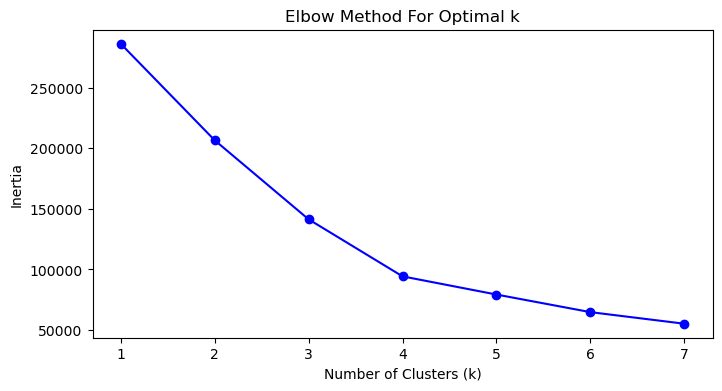

In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select the RFM features for clustering
rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

# 2. Standardize the features (mean = 0, variance = 1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# 3. Find the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [8]:
# 1. Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled)

# 2. Add the cluster labels back to our rfm_df dataframe
rfm_df['Cluster'] = cluster_labels

# 3. Calculate the average RFM values and customer count for each cluster
cluster_summary = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("Cluster Summary Profiles:")
print(cluster_summary)

Cluster Summary Profiles:
        Recency Frequency Monetary       
           mean      mean     mean  count
Cluster                                  
0        133.52      1.00   113.60  51886
1        393.69      1.00   114.48  38378
2        226.18      2.11   243.05   2883
3        244.35      1.01  1145.31   2273


In [9]:
# 1. Map human-readable names to your clusters
cluster_mapping = {
    0: 'Recent Customers',
    1: 'Inactive / Churned',
    2: 'Loyal Repeaters',
    3: 'VIP Big Spenders'
}

rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_mapping)

# 2. See the distribution of segments
print(rfm_df['Segment'].value_counts())

Segment
Recent Customers      51886
Inactive / Churned    38378
Loyal Repeaters        2883
VIP Big Spenders       2273
Name: count, dtype: int64


C:\Users\Anshul computers\AppData\Local\Temp\ipykernel_8668\3551741841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


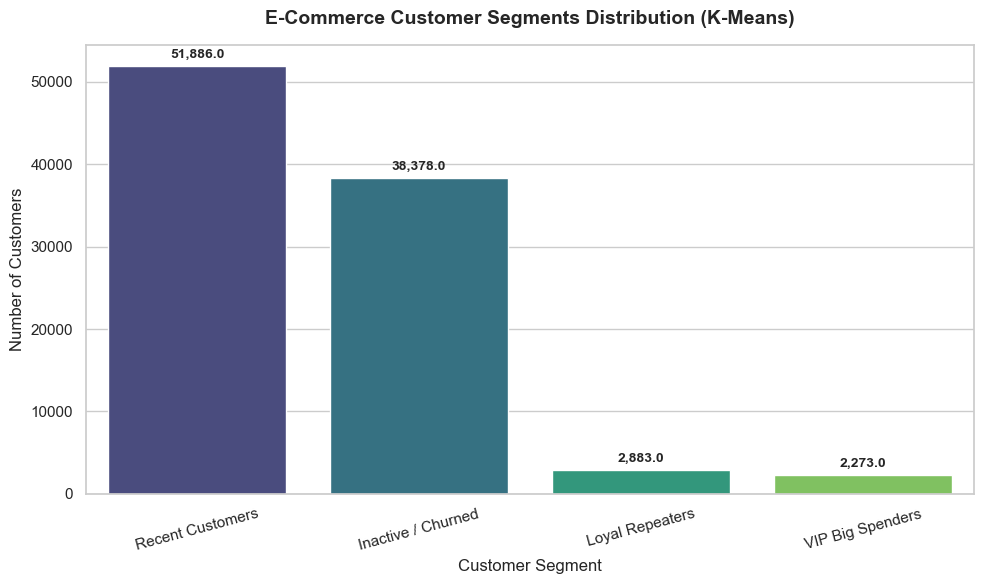

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Count the number of customers in each segment
segment_counts = rfm_df['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer_Count']

# 2. Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=segment_counts, 
    x='Segment', 
    y='Customer_Count', 
    palette='viridis'
)

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), ','), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title('E-Commerce Customer Segments Distribution (K-Means)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=15)

# Save the plot so you can add it to your GitHub README
plt.tight_layout()
plt.savefig('customer_segments_distribution.png', dpi=300)
plt.show()

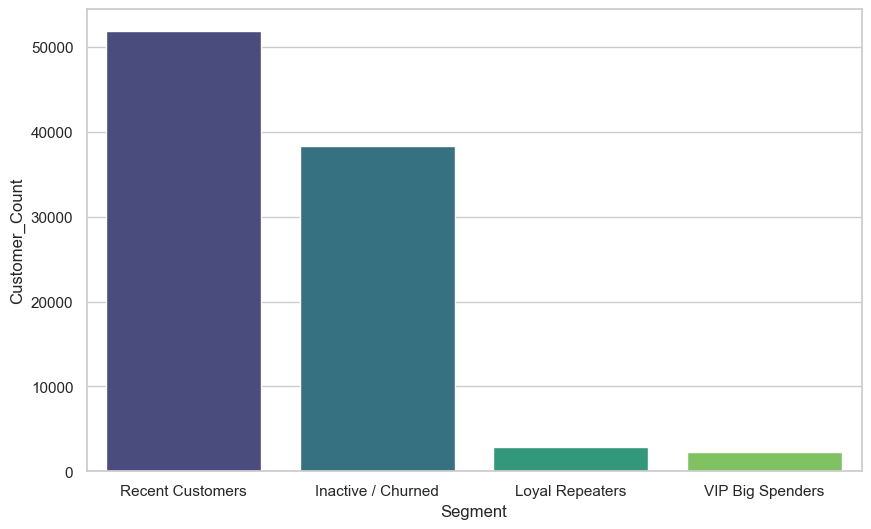

In [11]:
# 2. Create the bar plot (updated to fix the Seaborn warning)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=segment_counts, 
    x='Segment', 
    y='Customer_Count', 
    hue='Segment',       # Assigned hue to match x
    palette='viridis',
    legend=False         # Disabled legend since x-axis already shows segments
)